<a href="https://colab.research.google.com/github/yg36/PyTorch-Learning/blob/main/01_pytorch_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

In [ ]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start,end, step).unsqueeze(dim=1)
X[:10], len(X)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 50)

In [ ]:
y = weight *X + bias
y[:10], len(y)

(tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50)

train test split

In [ ]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

X_train

tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800],
        [0.2000],
        [0.2200],
        [0.2400],
        [0.2600],
        [0.2800],
        [0.3000],
        [0.3200],
        [0.3400],
        [0.3600],
        [0.3800],
        [0.4000],
        [0.4200],
        [0.4400],
        [0.4600],
        [0.4800],
        [0.5000],
        [0.5200],
        [0.5400],
        [0.5600],
        [0.5800],
        [0.6000],
        [0.6200],
        [0.6400],
        [0.6600],
        [0.6800],
        [0.7000],
        [0.7200],
        [0.7400],
        [0.7600],
        [0.7800]])

Needs better visualization : Use matplotlib

In [ ]:
import matplotlib
import matplotlib.pyplot as plt

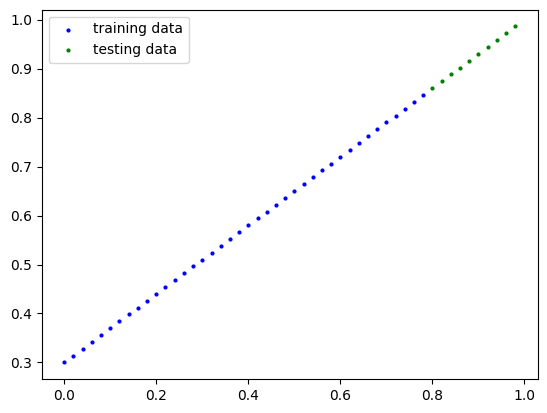

In [ ]:
plt.scatter(X_train, y_train, c="b", s=4, label="training data")
plt.scatter(X_test, y_test, c="g", s=4, label="testing data")
plt.legend(prop={"size": 10})

In [ ]:
# build the model
from torch import nn

class LinearRegressionModel(nn.Module):  # almost evrything inherits from nn.Module
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype= torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True,
                                         dtype=torch.float))
  def forward(self, x:torch.Tensor) -> torch.Tensor: # x is input data
    return self.weights * x + self.bias   # Linear Regression formula

In [ ]:
# manual_seed controls randomness across pytorch env
torch.manual_seed(42)

# creating instance of model
model_0 = LinearRegressionModel()

# Checking the nn.Parameter within nn.Module subclass we created(LinearRegressionModel(using its instance i.e. model_0))
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
# getting the state
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
# making predictions using inference_mode()
with torch.inference_mode():
  y_preds = model_0(X_test)

# inference_moel turns off gradient tracking which is necessary for training but not for predictions to make forward passing faster.

In [ ]:
# CHeck the predictions
print(f"Number od tetsing samples: {len(X_test)}")
print(f"Number of predictions: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number od tetsing samples: 10
Number of predictions: 10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


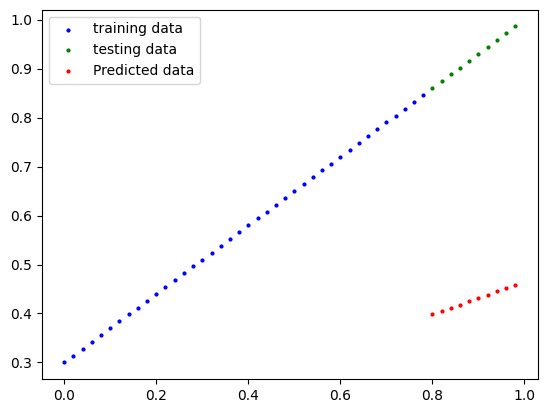

In [ ]:
plt.scatter(X_train, y_train, c="b", s=4, label="training data")
plt.scatter(X_test, y_test, c="g", s=4, label="testing data")
plt.scatter(X_test, y_preds, c="r", s=4, label="Predicted data")
plt.legend(prop={"size": 10})

Quite off

In [ ]:
# Lets see the difference
y_test - y_preds

tensor([[0.4618],
        [0.4691],
        [0.4764],
        [0.4836],
        [0.4909],
        [0.4982],
        [0.5054],
        [0.5127],
        [0.5200],
        [0.5272]])

Why this happended?

bcz we trained model only on X_test. It hasnt looked at blue dots to try to predict green dots

The model needs to update weights ad bias. In simpler terms, it needs to learn pattern.

To do so, we will create a loss function and an optimizer.

In [ ]:
# Mean Absolute Error = L1Loss
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

In [ ]:
# Lets make training and testing loop

torch.manual_seed(42)

epochs = 100

train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
  # Training

  # train the model
  model_0.train()

  # get predictions from X_train
  y_pred = model_0(X_train)

  # calculate loss
  loss = loss_fn(y_pred, y_train)

  # initialize model parameter's gradient to zero.
  optimizer.zero_grad()

  # use backpropagation
  loss.backward()

  # update the model parameter according to gradient calculated in backpropagation
  optimizer.step()


  ## Testing

  # Forward pass
  model_0.eval()

  # calculate predictions
  with torch.inference_mode():
    test_pred = model_0(X_test)

    # calculate loss
    loss_pred = loss_fn(test_pred, y_test)

    # print whats happening
    if epoch%10 == 0:
      epoch_count.append(epoch)
      train_loss_values.append(loss.detach().numpy())
      test_loss_values.append(loss_pred.detach().numpy())
      print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {loss_pred}")

Epoch: 0 | MAE Train Loss: 0.31288138031959534 | MAE Test Loss: 0.48106518387794495
Epoch: 10 | MAE Train Loss: 0.1976713240146637 | MAE Test Loss: 0.3463551998138428
Epoch: 20 | MAE Train Loss: 0.08908725529909134 | MAE Test Loss: 0.21729660034179688
Epoch: 30 | MAE Train Loss: 0.053148526698350906 | MAE Test Loss: 0.14464017748832703
Epoch: 40 | MAE Train Loss: 0.04543796554207802 | MAE Test Loss: 0.11360953003168106
Epoch: 50 | MAE Train Loss: 0.04167863354086876 | MAE Test Loss: 0.09919948130846024
Epoch: 60 | MAE Train Loss: 0.03818932920694351 | MAE Test Loss: 0.08886633068323135
Epoch: 70 | MAE Train Loss: 0.03476089984178543 | MAE Test Loss: 0.0805937647819519
Epoch: 80 | MAE Train Loss: 0.03132382780313492 | MAE Test Loss: 0.07232122868299484
Epoch: 90 | MAE Train Loss: 0.02788739837706089 | MAE Test Loss: 0.06473556160926819


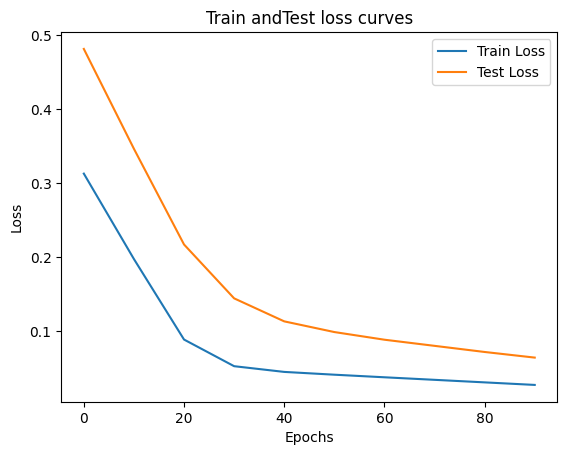

In [ ]:
plt.plot(epoch_count, train_loss_values, label = "Train Loss")
plt.plot(epoch_count, test_loss_values, label = "Test Loss")
plt.title("Train andTest loss curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend();

In [ ]:
# Inspecting state_dict()

print("The model leanrned the following values for weight and bias: ")
print(model_0.state_dict())
print("\n The original values for weight and bias was: ")
print(f"Weight: {weight}, Bias: {bias}")

The model leanrned the following values for weight and bias: 
OrderedDict({'weights': tensor([0.5784]), 'bias': tensor([0.3513])})

 The original values for weight and bias was: 
Weight: 0.7, Bias: 0.3


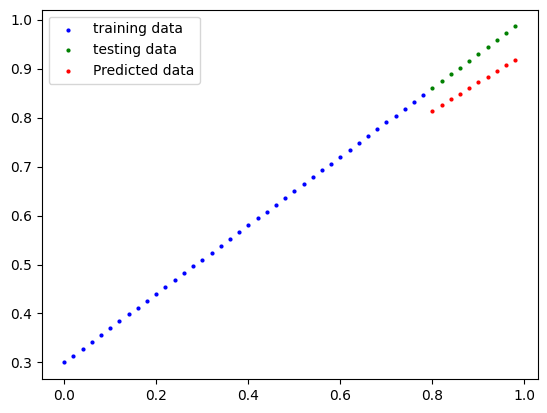

In [ ]:
# Plotting the new predictions

plt.scatter(X_train, y_train, c="b", s=4, label="training data")
plt.scatter(X_test, y_test, c="g", s=4, label="testing data")
plt.scatter(X_test, test_pred, c="r", s=4, label="Predicted data")
plt.legend()